Try using a denoising autoencoder to pretrain an image classifier. You can use MNIST (the simplest option), or a more complex image dataset such as CIFAR10 if you want a bigger challenge. Regardless of the dataset you’re using, follow these steps:
- Split the dataset into a training set and a test set. Train a deep denoising autoencoder on the full training set.
- Check that the images are fairly well reconstructed. Visualize the images that most activate each neuron in the coding layer.
- Build a classification DNN, reusing the lower layers of the autoencoder. Train it using only 500 images from the training set. Does it perform better with or without pretraining?


In [114]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T
import torchmetrics
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from collections import namedtuple

device = 'cuda'

In [3]:
ToTensor = T.Compose([T.ToImage(), T.ToDtype(dtype=torch.float32, scale=True)])

dataset = torchvision.datasets.CIFAR10(root='datas', train=True, transform=ToTensor)
train_dataset, valid_dataset = torch.utils.data.random_split(dataset, lengths=[45000, 5000])

class AEdataset(Dataset):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        x, _ = self.dataset[index]
        return x, x
    

train_loader = DataLoader(AEdataset(train_dataset), batch_size=32, shuffle=True)
valid_loader = DataLoader(AEdataset(valid_dataset), batch_size=32)

In [145]:
def eval_model(model, metric, valid_loader):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in valid_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            
    return metric.compute()

def train_model(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs, 
                factor=0.5, patience=2, epoch_callback=None, temperature_decrease=False, train_encoder=True):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor, patience)
    history = {'train_loss':[], 'train_metrics':[], 'valid_metrics':[]}
    
    for epoch in range(n_epochs):
        total_loss = 0.0
        model.train()
        metric.reset()
        
        if train_encoder == False:
            model.encoder.eval()
            for p in model.encoder.parameters():
                p.requires_grad = False
                
        if epoch_callback is not None:
            epoch_callback(model, epoch)
            
        if temperature_decrease == True:
            model.temperature = 1 - 0.7 * (epoch/n_epochs)
            
        for index, (X_batch, y_batch) in enumerate(train_loader):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            
            if isinstance(y_pred, tuple):
                y_pred = y_pred.output
            metric.update(y_pred, y_batch)
            train_metric = metric.compute().item()
            print(f'\rBatch: {index + 1}/{len(train_loader)}', end="")
            print(f', loss={total_loss/(index+1):.3f}', end="")
            print(f', {train_metric=:.2f}', end="")
            
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_metrics'].append(train_metric)
        val_metric = eval_model(model, metric, valid_loader)
        history['valid_metrics'].append(val_metric)
        
        scheduler.step(val_metric)
        print(f'\rEpoch: {epoch+1}/{n_epochs}\tTrain loss: {history["train_loss"][-1]:.3f}\tTrain metrics: {history['train_metrics'][-1]:.3f}\tValid metrics: {history['valid_metrics'][-1]:.3f}')
    
    return history

In [56]:
encoder = nn.Sequential(nn.Flatten(), nn.Linear(32*32*3, 1024), nn.ReLU(),
                        nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                        nn.Linear(512, 256), nn.ReLU())
decoder = nn.Sequential(nn.Linear(256, 512), nn.ReLU() , nn.Linear(512, 512), nn.ReLU(),
                        nn.Linear(512, 1024), nn.ReLU(),
                        nn.Linear(1024, 32*32*3), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(3, 32, 32)))
denoising_autoencoder = nn.Sequential(encoder, decoder).to(device)

nadam = torch.optim.NAdam(denoising_autoencoder.parameters())
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train_model(denoising_autoencoder, nadam, mse, rmse, train_loader, valid_loader, 50)

Epoch: 1/50	Train loss: 0.049	Train metrics: 0.222	Valid metrics: 0.209
Epoch: 2/50	Train loss: 0.044	Train metrics: 0.210	Valid metrics: 0.221
Epoch: 3/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.214
Epoch: 4/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.209
Epoch: 5/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.209
Epoch: 6/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.208
Epoch: 7/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.209
Epoch: 8/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.209
Epoch: 9/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.208
Epoch: 10/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.208
Epoch: 11/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.208
Epoch: 12/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.208
Epoch: 13/50	Train loss: 0.044	Train metrics: 0.209	Valid metrics: 0.208
Epoch: 14/50	Train loss: 0.044	Train metrics: 0.209	Valid me

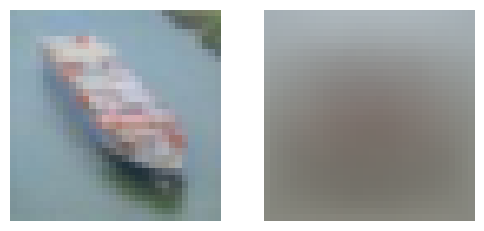

In [120]:
def plot_reconstruction(model, dataset, index=0):
    fig = plt.figure(figsize=(6, 6))

    an_image = dataset[index][0].permute(1, 2, 0)
    plt.subplot(1, 2, 1)
    plt.imshow(an_image)
    plt.axis('off')

    model.eval()
    with torch.no_grad():
        r_image = model(an_image.view(1, 32*32*3).to(device))
        
    if isinstance(r_image, tuple):
        r_image = r_image.output
        
    r_image = r_image.view(3, 32, 32)
    r_image = r_image.permute(1, 2, 0)
    r_image = r_image.cpu()
    r_image = torch.clamp(r_image, 0, 1)
    plt.subplot(1, 2, 2)
    plt.imshow(r_image)
    plt.axis('off')
    plt.show()
    
plot_reconstruction(denoising_autoencoder, valid_dataset, 0)

In [94]:
denoising_autoencoder.eval()
encoder.eval()
activations = encoder(valid_dataset[7][0].view(1, 3, 32, 32).to(device))
activation = encoder(valid_dataset[8][0].view(1, 3, 32, 32).to(device))
activations = torch.cat([activations, activations], dim=0)
activations.argmax(dim=1)

tensor([207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207,
        207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 207, 2

In [108]:
def neuron_activation(encoder, dataset):
    encoder.eval()
    activations = encoder(dataset[0][0].view(1, 3, 32, 32).to(device))
    for i in range(len(dataset)):
        activations = torch.cat([activations, encoder(dataset[i][0].view(1, 3, 32, 32).to(device))])
        
    return activations

activations = neuron_activation(encoder, valid_dataset)

def neuron_favorite_image(activations):
    neuron_and_image_indexes = []
    only_images = []
    activations = activations.argmax(dim=0)
    for i in range(len(activations)):
        if activations[i].item() != 0 and activations[i].item() not in only_images:
            neuron_and_image_indexes.append((i, activations[i].item()))
            only_images.append(activations[i].item())
            
    return neuron_and_image_indexes

NI = neuron_favorite_image(activations)
    

[(17, 2524), (50, 2841)]


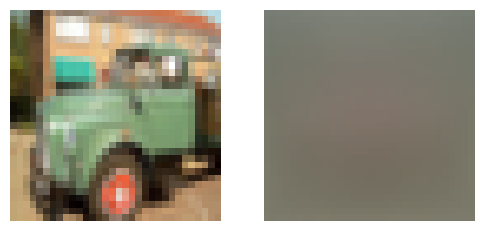

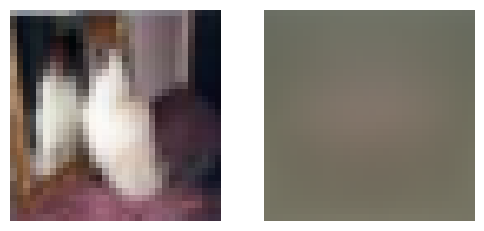

In [ ]:
#only 2 neurons work! better to build sparse model
print(NI)
plot_reconstruction(denoising_autoencoder, valid_dataset, 2524)
plot_reconstruction(denoising_autoencoder, valid_dataset, 2841)

In [115]:
SparseOutput = namedtuple("SparseOutput", ['output', 'codings'])

class SparseDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Flatten(), nn.Linear(32*32*3, 1024), nn.ReLU(),
                                nn.Linear(1024, 512), nn.ReLU(), nn.Linear(512, 512), nn.ReLU(),
                                nn.Linear(512, 256), nn.Sigmoid())
        self.decoder = nn.Sequential(nn.Linear(256, 512), nn.ReLU() , nn.Linear(512, 512), nn.ReLU(),
                                nn.Linear(512, 1024), nn.ReLU(),
                                nn.Linear(1024, 32*32*3), nn.Sigmoid(), nn.Unflatten(dim=1, unflattened_size=(3, 32, 32)))

    def forward(self, X):
        encodings = self.encoder(X)
        outputs = self.decoder(encodings)
        return SparseOutput(outputs, encodings)

sparse_model = SparseDenoisingAutoencoder().to(device)
nadam = torch.optim.NAdam(sparse_model.parameters())
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
mse = nn.MSELoss()

def mse_sparsity_loss(y_pred, y_target, target_sparsity=0.1, kl_weight=0.001, eps=1e-8):
    p = torch.tensor(target_sparsity, device=y_pred.codings.device)
    q = torch.clamp(y_pred.codings.mean(dim=0), eps, 1-eps)
    kl_div = p*torch.log(p/q) + (1-p)*torch.log((1-p)/(1-q))
    return mse(y_pred.output, y_target) + kl_weight * kl_div.sum()

history = train_model(sparse_model, nadam, mse_sparsity_loss, rmse, train_loader, valid_loader, 50)

Epoch: 1/50	Train loss: 0.048	Train metrics: 0.216	Valid metrics: 0.198
Epoch: 2/50	Train loss: 0.038	Train metrics: 0.195	Valid metrics: 0.197
Epoch: 3/50	Train loss: 0.037	Train metrics: 0.192	Valid metrics: 0.185
Epoch: 4/50	Train loss: 0.033	Train metrics: 0.182	Valid metrics: 0.179
Epoch: 5/50	Train loss: 0.032	Train metrics: 0.179	Valid metrics: 0.178
Epoch: 6/50	Train loss: 0.032	Train metrics: 0.179	Valid metrics: 0.178
Epoch: 7/50	Train loss: 0.032	Train metrics: 0.177	Valid metrics: 0.174
Epoch: 8/50	Train loss: 0.030	Train metrics: 0.173	Valid metrics: 0.172
Epoch: 9/50	Train loss: 0.030	Train metrics: 0.172	Valid metrics: 0.171
Epoch: 10/50	Train loss: 0.029	Train metrics: 0.169	Valid metrics: 0.167
Epoch: 11/50	Train loss: 0.028	Train metrics: 0.166	Valid metrics: 0.166
Epoch: 12/50	Train loss: 0.028	Train metrics: 0.166	Valid metrics: 0.165
Epoch: 13/50	Train loss: 0.028	Train metrics: 0.166	Valid metrics: 0.165
Epoch: 14/50	Train loss: 0.027	Train metrics: 0.165	Valid me

In [117]:
sparse_activations = neuron_activation(sparse_model.encoder, valid_dataset)
sparse_ni = neuron_favorite_image(sparse_activations)
print(sparse_ni)
print(len(sparse_ni))

[(0, 3423), (1, 2500), (2, 2524), (3, 4963), (4, 557), (6, 1562), (7, 3681), (13, 1714), (19, 753), (22, 310), (26, 4356), (29, 4720), (30, 2927), (32, 1086), (35, 3479), (46, 4355), (49, 994), (54, 3455), (67, 4927), (71, 4027), (72, 3257), (75, 957), (81, 4712), (92, 3995), (93, 1483), (120, 4583), (124, 195), (125, 4044), (135, 3728), (140, 2804), (143, 2563), (145, 64), (155, 2018), (157, 1900), (158, 494), (167, 3967), (206, 2241), (229, 463), (234, 4568), (240, 3202)]
40


In [ ]:
#all neurons work (I guess)
sparse_activations.argmax(dim=0)

tensor([3423, 2500, 2524, 4963,  557, 3423, 1562, 3681, 2524, 2524, 3423, 3423,
        3423, 1714, 3423, 2524, 3423, 3423, 3423,  753, 2524, 4963,  310, 2524,
        2524, 4963, 4356, 4963, 2524, 4720, 2927, 2927, 1086, 3423, 3423, 3479,
        3423, 2524, 2524, 4720, 2524, 2524, 3423, 2524, 2524, 2524, 4355, 2524,
        3423,  994,  753, 2524, 3423, 2524, 3455, 2524, 2500, 2524, 2524, 4720,
         557, 2524, 1562, 3479, 3423,  557, 2524, 4927, 2524, 4963, 2524, 4027,
        3257, 2927, 4927,  957,  753, 3479, 2524, 2524, 2927, 4712, 4963, 4720,
        3423, 2524, 2524, 2524, 2524, 2524, 1086, 4963, 3995, 1483, 2524, 1086,
        3479, 2524, 2524, 3423, 4963, 1086, 2524, 3423, 3423, 2524, 3423, 2524,
        2524, 2524, 1483,  753, 1562, 3423, 4963, 2524, 4963, 1562, 2927, 3423,
        4583, 4027, 2500, 3681,  195, 4044,  557, 2524,  957, 4963, 2524, 2927,
        2524, 2524, 3479, 3728, 2524, 2524, 2524, 3479, 2804, 2524, 3479, 2563,
        4720,   64, 2524, 3423, 4963, 25

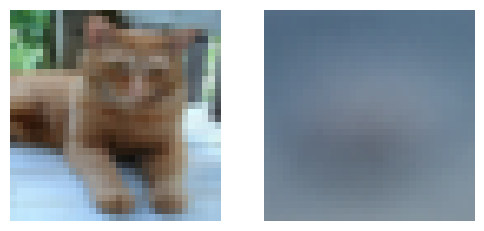

In [ ]:
#still very blury
plot_reconstruction(sparse_model, valid_dataset, 1900)

classification task

In [132]:
for i in range(100):
    print(train_dataset[i][1], end=" ")

6 3 7 4 5 4 9 8 8 2 3 6 0 0 7 0 3 4 1 6 6 7 0 5 9 6 6 2 8 7 8 1 3 3 0 1 7 6 7 6 5 7 5 6 7 7 1 1 5 9 2 9 2 3 5 9 0 1 5 4 1 3 0 0 2 2 7 4 6 2 6 1 9 7 9 4 7 5 9 4 0 4 9 3 6 9 3 3 1 5 8 6 2 0 7 3 6 0 3 6 

In [144]:
cls_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
cls_valid_loader = DataLoader(valid_dataset, batch_size=32)

class EncoderCls(nn.Module):
    def __init__(self, encoder, num_classes):
       super().__init__()
       self.encoder = encoder
       self.dnn = nn.Sequential(nn.Linear(256, 128), nn.ReLU(),
                          nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(),
                          nn.Linear(32, 10), nn.Softmax()).to(device)
       
    def forward(self, X):
        return self.dnn(self.encoder(X))
        
        
cls_model = EncoderCls(sparse_model.encoder, 10).to(device)


cls_model.eval()
with torch.no_grad():
    for X, y in cls_valid_loader:
        probas = cls_model(X.to(device)).argmax(dim=1)
        break
    
print(probas)
print(y)
print(torch.stack([y[i]==probas[i] for i in range(len(y))]).float().mean())

tensor([6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
        6, 6, 6, 6, 6, 6, 6, 6], device='cuda:0')
tensor([8, 8, 0, 2, 9, 6, 6, 2, 4, 3, 9, 3, 8, 5, 7, 2, 6, 1, 7, 1, 2, 2, 2, 0,
        1, 1, 6, 6, 3, 0, 4, 8])
tensor(0.1562, device='cuda:0')


/home/damian/New Folder/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [158]:
class RestrictedDataset(Dataset):
    def __init__(self, dataset, num_instances):
        self.dataset = [dataset[i] for i in range(num_instances)]
        
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, index):
        return self.dataset[index][0], self.dataset[index][1]

In [180]:
restricted_loader = DataLoader(RestrictedDataset(train_dataset, 500), batch_size=32, shuffle=True)
nadam = torch.optim.NAdam(params=cls_model.parameters())
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

history = train_model(cls_model, nadam, xentropy, accuracy, restricted_loader, cls_valid_loader, 500, train_encoder=False)

Epoch: 1/500	Train loss: 2.212	Train metrics: 0.236	Valid metrics: 0.183
Epoch: 2/500	Train loss: 2.212	Train metrics: 0.228	Valid metrics: 0.187
Epoch: 3/500	Train loss: 2.214	Train metrics: 0.222	Valid metrics: 0.188
Epoch: 4/500	Train loss: 2.207	Train metrics: 0.240	Valid metrics: 0.180
Epoch: 5/500	Train loss: 2.209	Train metrics: 0.234	Valid metrics: 0.185
Epoch: 6/500	Train loss: 2.213	Train metrics: 0.220	Valid metrics: 0.188
Epoch: 7/500	Train loss: 2.204	Train metrics: 0.246	Valid metrics: 0.184
Epoch: 8/500	Train loss: 2.203	Train metrics: 0.252	Valid metrics: 0.186
Epoch: 9/500	Train loss: 2.204	Train metrics: 0.238	Valid metrics: 0.187
Epoch: 10/500	Train loss: 2.202	Train metrics: 0.250	Valid metrics: 0.189
Epoch: 11/500	Train loss: 2.198	Train metrics: 0.250	Valid metrics: 0.187
Epoch: 12/500	Train loss: 2.199	Train metrics: 0.248	Valid metrics: 0.188
Epoch: 13/500	Train loss: 2.197	Train metrics: 0.248	Valid metrics: 0.188
Epoch: 14/500	Train loss: 2.201	Train metrics: 

In [188]:
#It seems to be same but with high error distribution now
cls_model.eval()
with torch.no_grad():
    for X, y in cls_train_loader:
        probas = cls_model(X.to(device)).argmax(dim=1)
        break
    
print(probas)
print(y)
print(torch.stack([y[i]==probas[i] for i in range(len(y))]).float().mean())

tensor([1, 6, 6, 0, 8, 8, 6, 1, 6, 0, 1, 0, 6, 6, 1, 6, 6, 1, 1, 1, 8, 8, 8, 1,
        1, 6, 8, 0, 0, 6, 1, 8], device='cuda:0')
tensor([1, 1, 6, 3, 5, 0, 7, 2, 9, 3, 5, 5, 5, 3, 3, 0, 4, 7, 2, 1, 9, 9, 0, 6,
        4, 4, 0, 9, 4, 4, 9, 3])
tensor(0.0938, device='cuda:0')


In [189]:
#orig denoising model
cls_model_2 = EncoderCls(encoder, 10).to(device)

nadam = torch.optim.NAdam(params=cls_model_2.parameters())
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

history = train_model(cls_model_2, nadam, xentropy, accuracy, restricted_loader, cls_valid_loader, 150, train_encoder=False)

Epoch: 1/150	Train loss: 2.301	Train metrics: 0.094	Valid metrics: 0.104
Epoch: 2/150	Train loss: 2.299	Train metrics: 0.146	Valid metrics: 0.104
Epoch: 3/150	Train loss: 2.284	Train metrics: 0.138	Valid metrics: 0.141
Epoch: 4/150	Train loss: 2.270	Train metrics: 0.188	Valid metrics: 0.157
Epoch: 5/150	Train loss: 2.259	Train metrics: 0.190	Valid metrics: 0.158
Epoch: 6/150	Train loss: 2.253	Train metrics: 0.184	Valid metrics: 0.158
Epoch: 7/150	Train loss: 2.253	Train metrics: 0.186	Valid metrics: 0.158
Epoch: 8/150	Train loss: 2.252	Train metrics: 0.186	Valid metrics: 0.156
Epoch: 9/150	Train loss: 2.250	Train metrics: 0.178	Valid metrics: 0.156
Epoch: 10/150	Train loss: 2.248	Train metrics: 0.186	Valid metrics: 0.143
Epoch: 11/150	Train loss: 2.249	Train metrics: 0.170	Valid metrics: 0.142
Epoch: 12/150	Train loss: 2.248	Train metrics: 0.184	Valid metrics: 0.157
Epoch: 13/150	Train loss: 2.246	Train metrics: 0.194	Valid metrics: 0.156
Epoch: 14/150	Train loss: 2.244	Train metrics: 

In [190]:
#19% accuracy for sparse and 15% for denoising
cls_model_2.eval()
with torch.no_grad():
    for X, y in cls_train_loader:
        probas = cls_model_2(X.to(device)).argmax(dim=1)
        break
    
print(probas)
print(y)
print(torch.stack([y[i]==probas[i] for i in range(len(y))]).float().mean())

tensor([6, 6, 0, 6, 6, 6, 0, 6, 6, 0, 6, 6, 0, 6, 8, 6, 6, 6, 6, 0, 0, 0, 0, 6,
        6, 0, 6, 6, 6, 9, 6, 6], device='cuda:0')
tensor([5, 0, 9, 6, 1, 5, 9, 1, 7, 7, 0, 6, 3, 1, 3, 5, 4, 0, 2, 7, 2, 8, 0, 6,
        7, 8, 1, 7, 7, 5, 4, 8])
tensor(0.1250, device='cuda:0')


/home/damian/New Folder/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
